# Synthetic Pancreatic Cancer Data

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

In [3]:
#read in data
pan_data = pd.read_csv('pancreatic_cancer_dataset.csv')
pan_data.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Ethnicity,Smoking_Status,Pack_Years,...,Treatment,Surgery_Performed,Surgical_Margin,Lymph_Node_Status,Vascular_Involvement,Perineural_Invasion,ECOG_Score,Survival_Months,Survived,Five_Year_Status
0,PC-0001,2020,2020-11-04,Western Pacific,China,54,Female,White/Caucasian,Current Smoker,33,...,Chemotherapy (FOLFIRINOX),No,NaN,Negative,NaN,Yes,1,11,No,Deceased
1,PC-0002,2022,2022-12-09,Americas,Mexico,66,Female,South Asian,Current Smoker,40,...,Chemotherapy (Gemcitabine),No,NaN,Positive,NaN,No,1,25,No,Deceased
2,PC-0003,2021,2021-04-05,Europe,Germany,68,Male,Black/African,Former Smoker,15,...,Targeted Therapy (Erlotinib),No,NaN,Positive,Multiple Vessels,No,2,20,No,Deceased
3,PC-0004,2019,2019-11-24,South-East Asia,Timor-Leste,68,Male,White/Caucasian,Current Smoker,59,...,Chemotherapy (FOLFIRINOX),No,NaN,Negative,SMV (Superior Mesenteric Vein),Yes,3,3,No,Deceased
4,PC-0005,2022,2022-02-19,Europe,Turkey,70,Male,Black/African,Current Smoker,39,...,Distal Pancreatectomy,Yes,R1 (Microscopic Positive),Positive,Portal Vein,Yes,3,6,No,Deceased


In [5]:
print(pan_data.shape)
pan_data.isna().sum()

(2000, 51)


Patient_ID                 0
Diagnosis_Year             0
Diagnosis_Date             0
WHO_Region                 0
Country                    0
Age                        0
Gender                     0
Ethnicity                  0
Smoking_Status             0
Pack_Years                 0
Alcohol_Use              586
BMI                        0
BMI_Category               0
Diabetes_Status            0
Chronic_Pancreatitis       0
Family_History             0
Hereditary_Syndrome     1827
Blood_Group                0
Genetic_Mutation           0
Cancer_Type                0
Tumor_Location             0
Cancer_Stage               0
Resectability              0
Tumor_Size_cm              0
Tumor_Grade                0
Metastasis_Site            0
Biomarker_Status           0
CA_19_9_Level              0
Jaundice                   0
Abdominal_Pain             0
Back_Pain                  0
Weight_Loss                0
Loss_of_Appetite           0
Nausea_Vomiting            0
New_Onset_Diab

In [6]:
#eh, might as well drop the cols Hereditary_Syndrome and Surgical_MArgin since the NAs are so high...otherwise looks ok
pan_data = pan_data.drop(columns=['Hereditary_Syndrome', 'Surgical_Margin'])


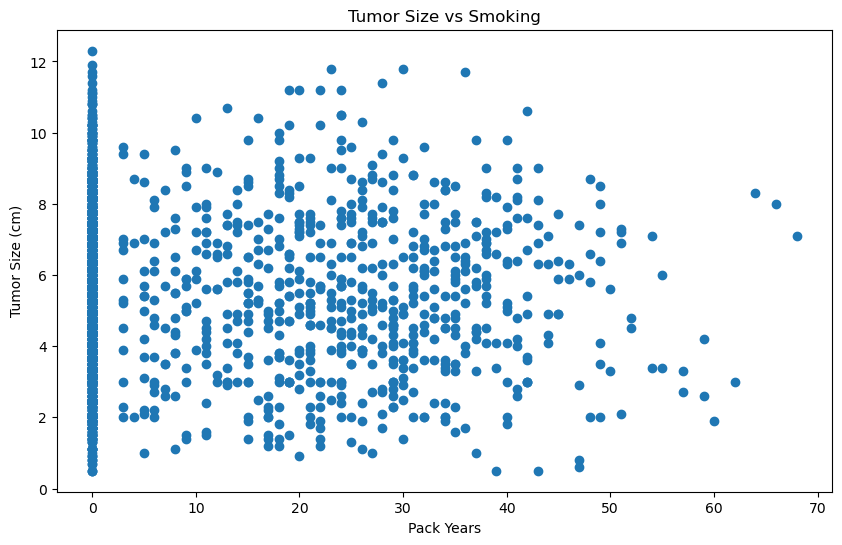

In [ ]:
#quick viz ...what looks interesting... maybe smoking and tumor size? (noted above we have no NANs in pack years, so that should be ok to use)
plt.figure(figsize=(10, 6))
plt.scatter(pan_data['Pack_Years'], pan_data['Tumor_Size_cm'])
plt.xlabel('Pack Years')
plt.ylabel('Tumor Size (cm)')
plt.title('Tumor Size vs Smoking')
plt.show()

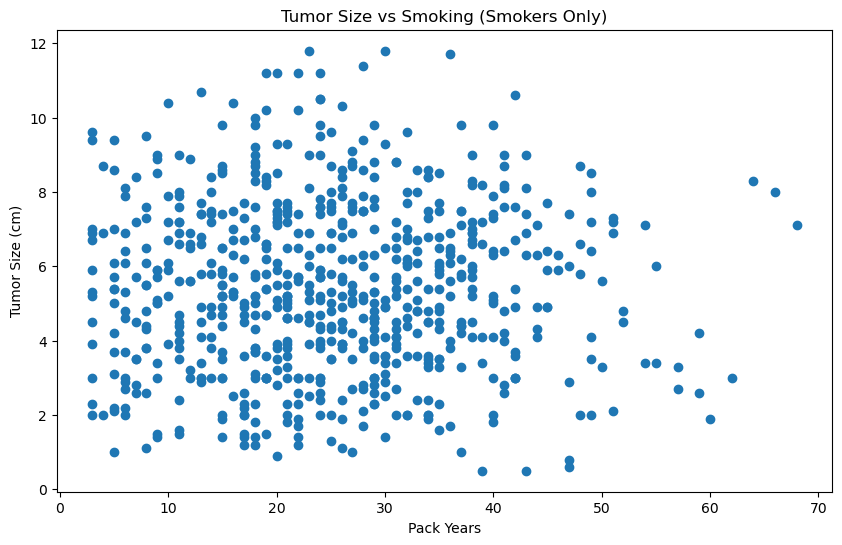

In [13]:
#ah, right, the 0 pack years / non-smokers should maybe be considered a separate subpopulation. COuld be interesting to do some clustering. 
# let;s look at just the pack years for 1 and greater
smokers = pan_data[pan_data['Pack_Years'] > 0]
plt.figure(figsize=(10, 6))
plt.scatter(smokers['Pack_Years'], smokers['Tumor_Size_cm'])
plt.xlabel('Pack Years')
plt.ylabel('Tumor Size (cm)')
plt.title('Tumor Size vs Smoking (Smokers Only)')
plt.show()

In [14]:
#hmm maybe a weak positive? let's check the correlation coefficients
correlation = smokers['Pack_Years'].corr(smokers['Tumor_Size_cm'])
print(correlation)

0.007981804120731729


In [19]:
#yep, very weak posiitive. What about the non-smokers vs smokers? could be a case for ANOVA?
non_smokers = pan_data[pan_data['Pack_Years'] == 0]
smoker_tumor_sizes = smokers['Tumor_Size_cm']
non_smoker_tumor_sizes = non_smokers['Tumor_Size_cm']
mean_smoker = smoker_tumor_sizes.mean()
mean_non_smoker = non_smoker_tumor_sizes.mean()
print(f"mean tumor size for smokers: {mean_smoker}")
print(f"mean tumor size for nonsmokers: {mean_non_smoker}")


mean tumor size for smokers: 5.425979680696662
mean tumor size for nonsmokers: 5.4209000762776505


In [20]:
#looks pretty close, lets do the ANOVA to be sure
f_statistic, p_value = stats.f_oneway(smoker_tumor_sizes, non_smoker_tumor_sizes)
print(f"ANOVA F-statistic: {f_statistic} and  p-value: {p_value}")

ANOVA F-statistic: 0.002342612534444943 and  p-value: 0.9614018642286967


really low F-stat at .002 means difference is basically noise... p-val is really high, not even close to indicating significance
   
     
of course, this is all synthetic data, so we can't draw any conclusions about reality, but it does help understand the data a bit so we can have a better intuition for any ML 


In [21]:
#write out the (barely) cleaned data
pan_data.to_csv('pancreatic_cancer_dataset_cleaned.csv', index=False)
